# Malaria model ranking — new machinery (`idd_tools.model_selection`)

Digests a finalized selection run (`selection_summary.parquet`) over the **typed** malaria
model space. Same shape as the earlier `rank_malaria_models` notebooks
(Kendall&nbsp;τ → Borda → TOPSIS → Pareto → dominance → consensus), plus what the typed
space adds: a **parsimony pick** over the structural down-set, and **slicing** by
`fiber` / `neighbors` / `down_set`.

Run it with the **`idd-forecast-mbp`** conda env as the kernel. Change only `RUN_DIR`.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from idd_forecast_mbp.select.malaria_spec_design import build_universe, AXIS_ORDER, n_scams as n_scams_of, n_terms as n_terms_of

from idd_tools.model_selection import (
    kendall_tau_matrix, prune_redundant_metrics, borda_rank, topsis_rank, pareto_frontier,
    pairwise_dominance_summary, consensus_rank, winner_profile,
    parsimonious_selection, neighbors, down_set, fiber, config_key,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110
sns.set_style("white")

## Paths — the one thing to edit per run

In [2]:
RUN_DIR = Path(
    "/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_prelim/lsae_1285/20260727_efs"
)
summary = pd.read_parquet(RUN_DIR / "selection_summary.parquet")
print(f"{len(summary):,} specs x {summary.shape[1]} cols from {RUN_DIR.name}")

1,620 specs x 310 cols from 20260727_efs


## Bridge `spec_index` → typed model space

`build_universe()` yields the 1,620 configs in `spec_index` order (`configs[i] ↔ spec_index i+1`).
Attaching the 7 group-axis columns is what lets us rank, profile, and **slice** structurally
instead of grepping formula strings.

In [3]:
universe = build_universe()
space = universe.space
AXES = list(AXIS_ORDER)                                   # g1_dah ... g7_humid

configs = pd.DataFrame(universe.configs)
configs["spec_index"] = np.arange(1, len(configs) + 1)    # configs[i] <-> spec_index i+1
df = summary.merge(configs, on="spec_index", how="left", validate="1:1")
assert df[AXES].notna().all().all(), "spec_index -> Config bridge is incomplete"

# n_scams (# shape-constrained / monotone terms) is a pure function of the config, and
# n_scams <= n_smooths. finalize doesn't carry it into selection_summary, so derive it here.
if "n_scams" not in df.columns:
    df["n_scams"] = [n_scams_of(universe.configs[i - 1]) for i in df["spec_index"]]
df["n_terms"] = [n_terms_of(universe.configs[i - 1]) for i in df["spec_index"]]   # all terms (linear too) -> parsimony
df[["spec_index", "n_smooths", "n_scams", "n_terms", *AXES]].head()

,spec_index,n_smooths,n_scams,n_terms,g1_dah,g2_gdp,g3_suit,g4_temp,g5_urban,g6_precip,g7_humid
0,1,0,0,0,out,out,out,out,out,out,out
1,2,1,1,1,out,out,out,out,out,out,relative_humidity|mpi
2,3,0,0,1,out,out,out,out,out,out,logit_relative_humidity|linear
3,4,0,0,1,out,out,out,out,out,total_precipitation|linear,out
4,5,1,1,2,out,out,out,out,out,total_precipitation|linear,relative_humidity|mpi


## Window-average the OOS metrics

10 temporal CV windows. Average each OOS metric across windows for one value per spec
(`*__mean`); also keep the worst window (`*__worst`). Per-window columns stay on `df` for the
winner deep-dive.

In [4]:
from idd_forecast_mbp.select.malaria_metrics import register_malaria_metrics, windowed
from idd_tools.model_selection import select_metrics, Sample
register_malaria_metrics()   # declare this run's metric vocabulary into the shared registry

WINDOWS = sorted({c.split("__")[0] for c in df.columns if "__oos_pfpr_r" in c})
print(f"{len(WINDOWS)} CV windows: {WINDOWS}")

# Ranking criteria: pick from the registry by metadata (searchable -- no hand-coded dict),
# then cross with ALL windows so each (window, metric) is its own criterion. Mirrors the
# repo's report; the Kendall-tau prune in the next cell collapses the ones that co-move.
specs   = select_metrics(sample=Sample.OUT_OF_SAMPLE, space="pfpr")   # 3 PfPR-space OOS metrics
metrics = windowed(specs, WINDOWS)                                    # 3 x 10 = 30 criteria
print(f"{len(specs)} PfPR OOS metrics x {len(WINDOWS)} windows = {len(metrics)} ranking criteria")

# Display-only per-model summary (a readable single number for the tables -- NOT a ranking
# criterion; the ranking uses all windows above).
mean_metrics = {}
for spec in specs:
    df[f"{spec.name}__mean"] = df[[f"{w}__{spec.name}" for w in WINDOWS]].mean(axis=1)
    mean_metrics[f"{spec.name}__mean"] = spec.orientation.value

config_cols = ["spec_index", "formula_text", "n_smooths", *AXES]

10 CV windows: ['exwide_recent', 'narrow_full', 'narrow_preC', 'narrow_recent', 'vwide_full', 'vwide_preC', 'vwide_recent', 'wide_full', 'wide_preC', 'wide_recent']
3 PfPR OOS metrics x 10 windows = 30 ranking criteria


## Optional cull — drop non-converged in-sample fits

In [5]:
CULL_NONCONVERGED = False
if CULL_NONCONVERGED and "is_converged" in df:
    before = len(df)
    df = df[df["is_converged"].fillna(False)].copy()
    print(f"culled {before - len(df)} non-converged specs -> {len(df)} remain")
else:
    print(f"no cull; {len(df)} specs")

no cull; 1620 specs


## Kendall τ — metric redundancy

High `|τ|` between two metrics means they rank models near-identically (RMSE / MAE / R² co-move).
Redundant criteria double-count the same signal in Borda / consensus — the heatmap is how you
spot a pair to drop from `OOS_METRICS`. Lower triangle only (the matrix is symmetric).

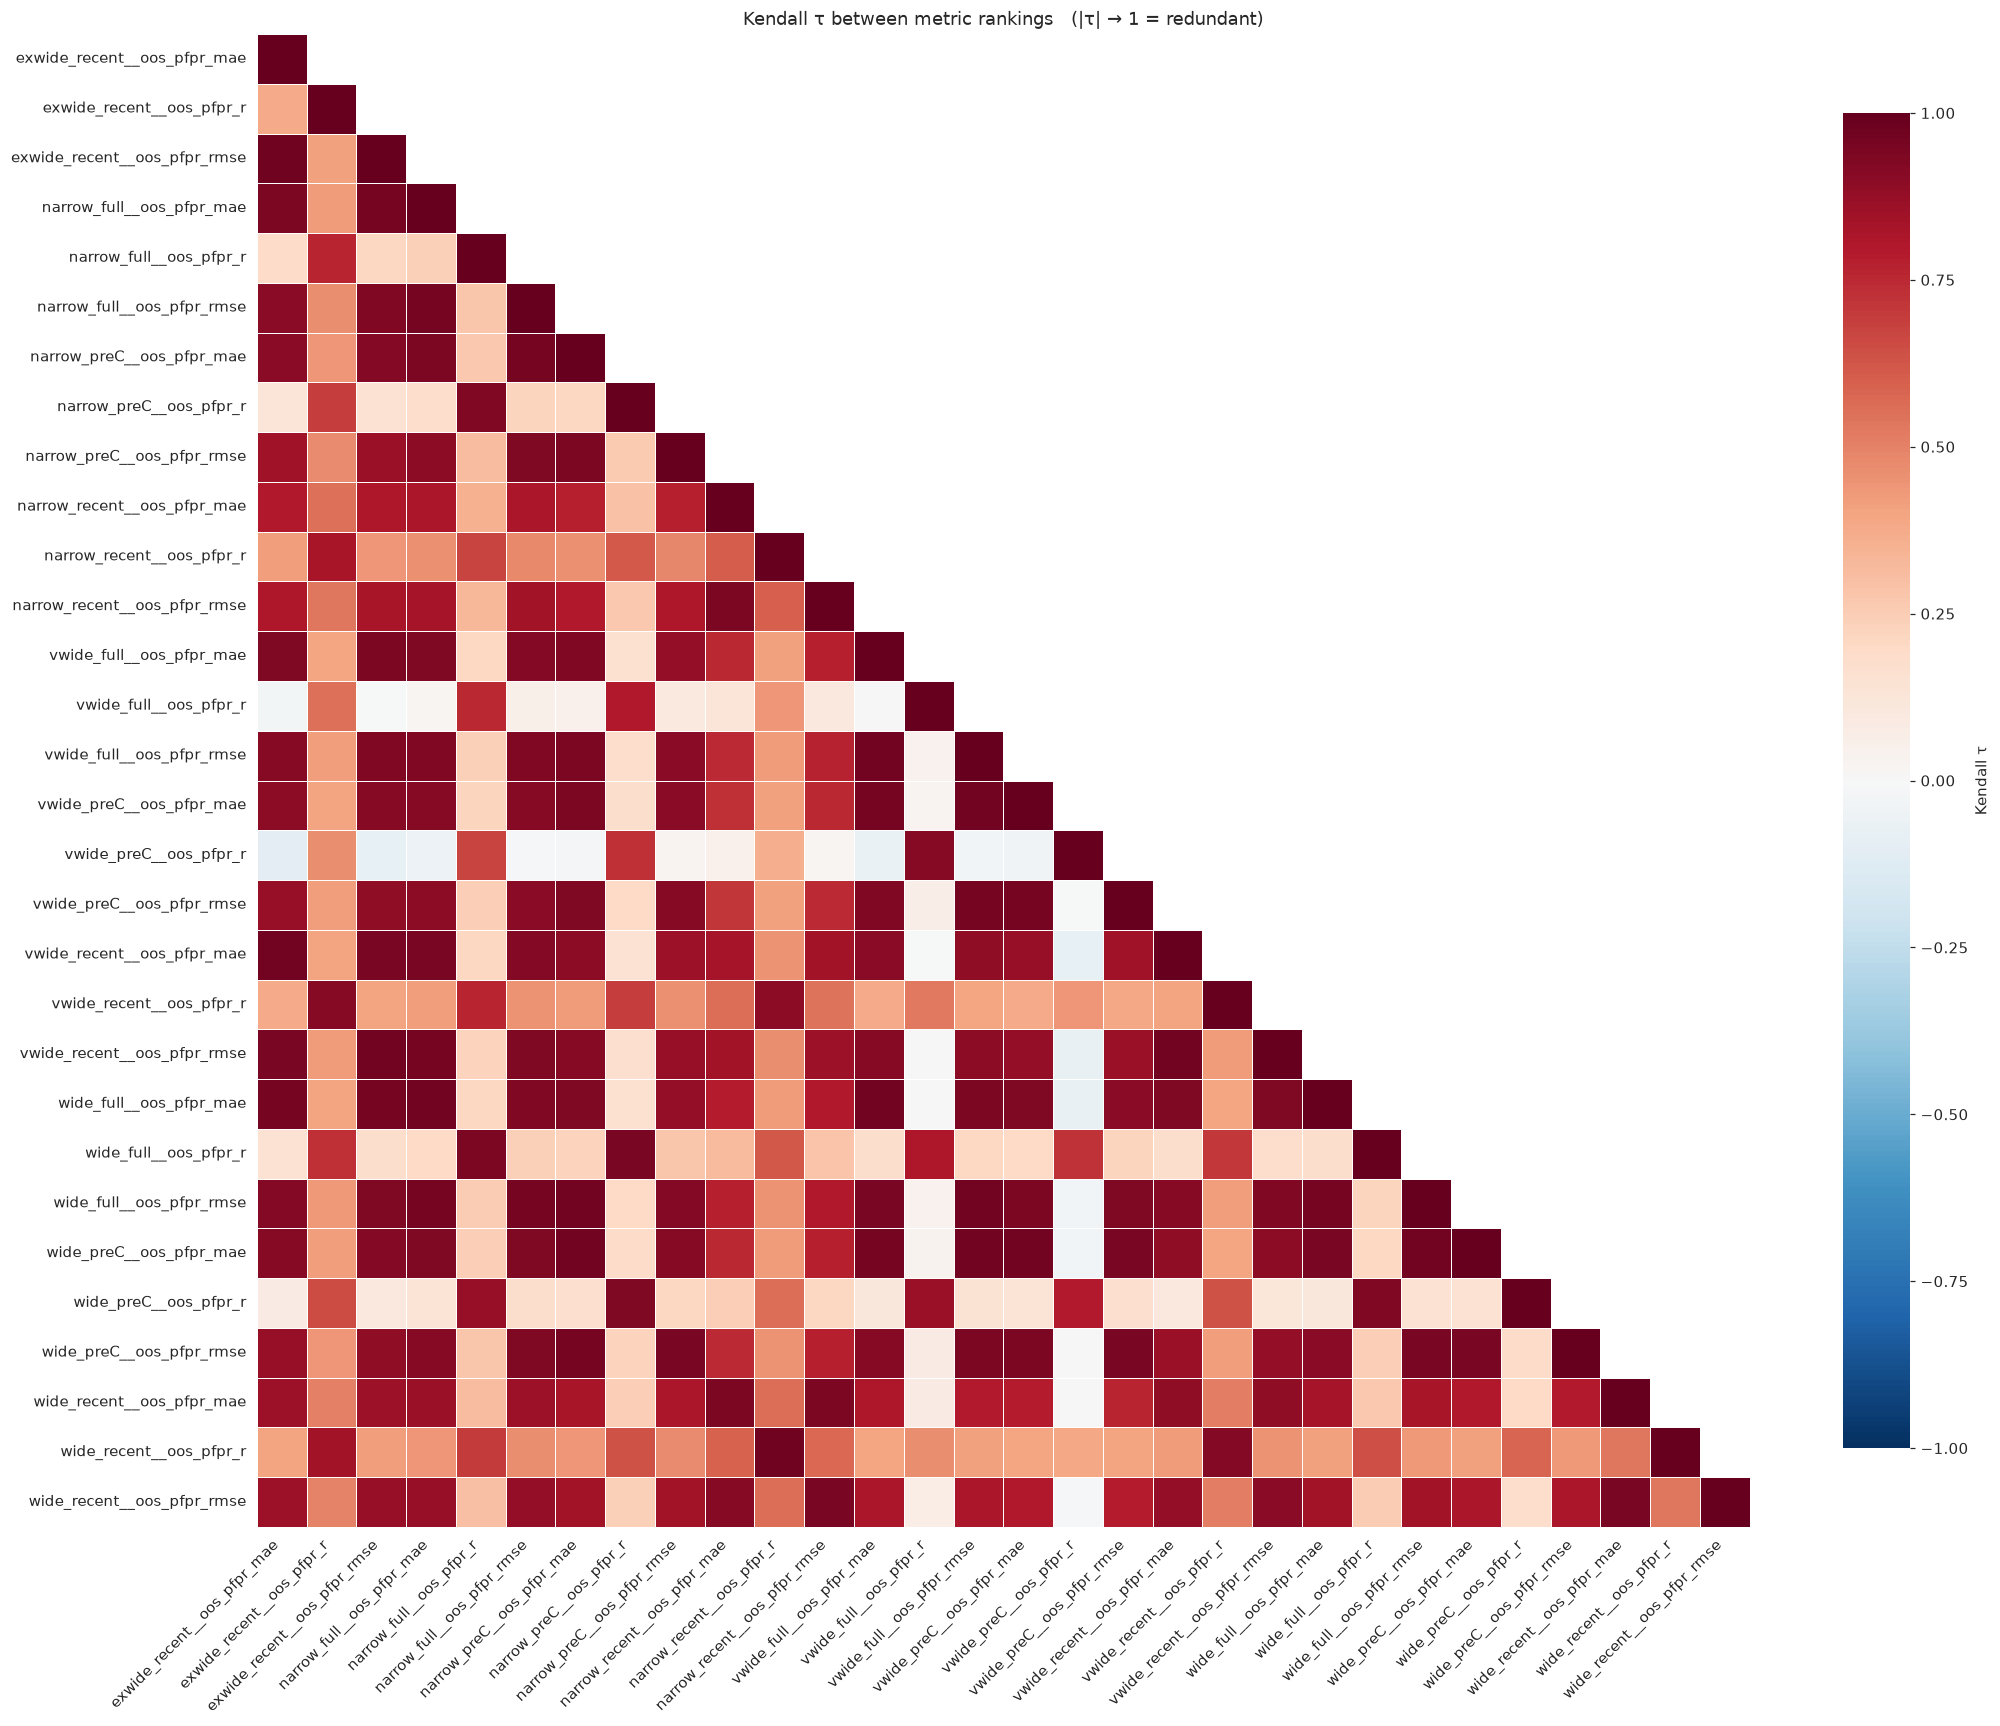

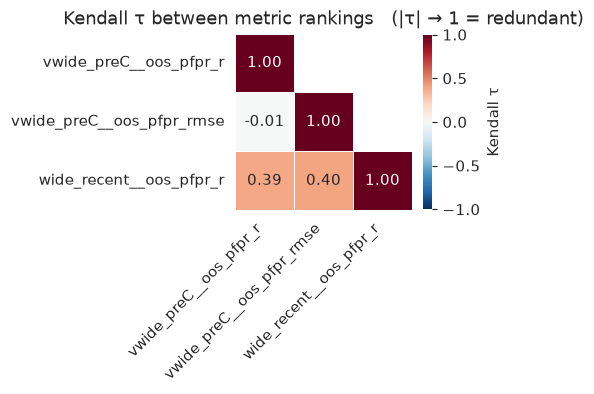

In [6]:
from idd_tools.model_selection import plot_kendall_tau

tau = kendall_tau_matrix(df, metrics)
plot_kendall_tau(tau);
pruned_metrics, log = prune_redundant_metrics(tau, metrics)
tau = kendall_tau_matrix(df, pruned_metrics)
plot_kendall_tau(tau);

## Borda count, TOPSIS, Pareto frontier, Pairwise dominance

In [7]:
borda_df, borda_cutpoint = borda_rank(df, pruned_metrics)
topsis_df, topsis_influence = topsis_rank(df, pruned_metrics)
pareto = pareto_frontier(df, pruned_metrics)
dominance_df = pairwise_dominance_summary(df, pruned_metrics)

In [8]:
ranks = (
    borda_df[["spec_index", "borda_rank", "borda_score"] + list(pruned_metrics.keys())]
    .merge(topsis_df[["spec_index", "topsis_rank", "topsis_score"]], on="spec_index")
    .merge(dominance_df[["spec_index", "dominance_rank"]], on="spec_index")
)
consensus = (consensus_rank(ranks)
             .merge(df[["spec_index", "n_smooths", "n_scams", "formula_text", *AXES]], on="spec_index")
             .sort_values("topsis_rank"))
consensus["on_pareto"] = consensus["spec_index"].isin(set(pareto["spec_index"]))
consensus.head(15)[
    ["spec_index", "n_smooths", "n_scams", "consensus_rank", "on_pareto",
     "borda_rank", "borda_score", "topsis_rank", "topsis_score", "dominance_rank"] + list(pruned_metrics.keys())
]

,spec_index,n_smooths,n_scams,consensus_rank,on_pareto,borda_rank,borda_score,topsis_rank,topsis_score,dominance_rank,vwide_preC__oos_pfpr_r,vwide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_r
1,1585,3,3,2.0,True,2.5,164.0,1.0,0.891736,4.5,0.780329,0.104349,0.823675
3,1612,4,3,4.0,True,1.0,163.0,2.0,0.891635,6.5,0.780903,0.104321,0.821876
2,1567,2,2,3.0,True,4.0,171.0,3.0,0.890193,2.0,0.779953,0.103618,0.823872
0,1594,3,2,1.0,True,2.5,164.0,4.0,0.889639,1.0,0.780401,0.103613,0.822049
4,1486,2,2,5.0,False,5.0,183.0,5.0,0.888062,3.0,0.779811,0.103627,0.822950
5,1576,2,2,6.0,False,7.0,194.0,6.0,0.886451,6.5,0.779532,0.104318,0.823392
6,1603,3,2,7.0,False,6.0,184.0,7.0,0.886214,8.0,0.780170,0.104301,0.821582
7,1504,3,3,8.0,False,8.0,202.0,8.0,0.885567,10.0,0.779781,0.104557,0.822286
9,1495,2,2,10.0,False,9.0,233.0,9.0,0.880874,11.0,0.779092,0.104500,0.822090
10,1450,4,4,11.0,False,10.0,288.0,10.0,0.876745,12.5,0.778007,0.104871,0.823714


## Winner profile — per-axis agreement in the top tier

For the top-N consensus models, what does each axis mostly choose? `mode_pct` near 100 = the
good models agree on that term; low `mode_pct` = the axis is genuinely contested.

In [9]:
winner_profile(consensus, id_cols=AXES, top_n=10)

,mode,mode_count,mode_pct,n_unique
g1_dah,mal_DAH_total_per_capita|mpd,10,100.0,1
g2_gdp,gdppc_mean|mpd,10,100.0,1
g3_suit,logit_malaria_suitability|linear,9,90.0,2
g4_temp,mean_low_temperature|linear,4,40.0,3
g5_urban,weighted_1km_urban_threshold_300.0_simple_mean...,4,40.0,3
g6_precip,out,10,100.0,1
g7_humid,out,10,100.0,1


## Parsimony pick — simplest model within tolerance

Over the **structural down-set** (models nested-simpler than the best), take the simplest whose
window-mean PfPR RMSE is within `tol` of the best.

In [10]:
focus_metric = "topsis_score" #"borda_score" | "topsis_score"
scored = df.merge(topsis_df[["spec_index", "topsis_score"]], on="spec_index")  # score lives on topsis_df
scored = scored.merge(borda_df[["spec_index", "borda_score"]], on="spec_index")  # score lives on topsis_df
tol = float(scored[focus_metric].std() * 0.25)

pick = parsimonious_selection(
    scored, metric=focus_metric, complexity=["n_scams","n_smooths","n_terms"], tol=tol,
    direction="higher",                       # topsis closeness: higher = better
    config_cols=AXES, space=space,
)
anchor, chosen = pick["anchor"], pick["pick"]
print(f"tolerance +/-{tol:.4f} on {focus_metric};  {pick['n_candidates']} candidates in the down-set\n")
print(f"best   : spec {int(anchor['spec_index'])}  n_smooths={int(anchor['n_smooths'])} "
      f"n_scams={int(anchor['n_scams'])}  {focus_metric}={anchor[focus_metric]:.4f}")
print(f"         {anchor['formula_text']}\n")
print(f"picked : spec {int(chosen['spec_index'])}  n_smooths={int(chosen['n_smooths'])} "
      f"n_scams={int(chosen['n_scams'])}  {focus_metric}={chosen[focus_metric]:.4f}")
print(f"         {chosen['formula_text']}")


tolerance +/-0.0371 on topsis_score;  6 candidates in the down-set

best   : spec 1585  n_smooths=3 n_scams=3  topsis_score=0.8917
         logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_low_temperature + s(weighted_1km_urban_threshold_300.0_simple_mean, k = 4, bs = "mpd") + A0_af

picked : spec 1486  n_smooths=2 n_scams=2  topsis_score=0.8881
         logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + A0_af


In [11]:
scored[focus_metric].std()

np.float64(0.14848440183301653)

In [12]:
scored = scored.sort_values(focus_metric, ascending=False)
scored[["spec_index", "borda_score", "topsis_score", "n_smooths", "n_scams"] + list(pruned_metrics.keys())].head(20)

,spec_index,borda_score,topsis_score,n_smooths,n_scams,vwide_preC__oos_pfpr_r,vwide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_r
1584,1585,164.0,0.891736,3,3,0.780329,0.104349,0.823675
1611,1612,163.0,0.891635,4,3,0.780903,0.104321,0.821876
1566,1567,171.0,0.890193,2,2,0.779953,0.103618,0.823872
1593,1594,164.0,0.889639,3,2,0.780401,0.103613,0.822049
1485,1486,183.0,0.888062,2,2,0.779811,0.103627,0.822950
1575,1576,194.0,0.886451,2,2,0.779532,0.104318,0.823392
1602,1603,184.0,0.886214,3,2,0.780170,0.104301,0.821582
1503,1504,202.0,0.885567,3,3,0.779781,0.104557,0.822286
1494,1495,233.0,0.880874,2,2,0.779092,0.104500,0.822090
1449,1450,288.0,0.876745,4,4,0.778007,0.104871,0.823714


## Slice & inspect — `neighbors` / `down_set` / `up_set` / `fiber`

Structural moves off the consensus winner. Every table carries **`changed_from_winner`** (`format_config_diff` — exactly which terms differ, `winner → this`) and **`n_changed`** (how many axes differ = structural distance), so you can read *what each model is* at a glance; `oos_pfpr_rmse__mean` + `consensus_rank` give the performance side.

In [13]:
from idd_tools.model_selection import format_config, format_config_diff, up_set

pd.set_option("display.max_colwidth", None)      # never truncate the diff / formula columns

key_to_spec = {config_key(c): i + 1 for i, c in enumerate(universe.configs)}
cfg_by_spec = {i + 1: c for i, c in enumerate(universe.configs)}

WINNER = int(consensus.iloc[0]["spec_index"])
winner_cfg = universe.configs[WINNER - 1]
print(f"consensus winner = spec {WINNER}")
print(format_config(winner_cfg, space))          # the winner's active terms, one line

def rows_for(cfgs):
    """Configs -> summary rows, tagged with consensus rank, structural distance, and the
    per-axis diff vs. the winner (so you can see what each model is)."""
    idx = [key_to_spec[config_key(c)] for c in cfgs]
    out = (df[df["spec_index"].isin(idx)]
           .merge(consensus[["spec_index", "consensus_rank", "topsis_score"]], on="spec_index")
           .sort_values("consensus_rank").copy())
    out["n_changed"] = [sum(cfg_by_spec[s][a] != winner_cfg[a] for a in AXES) for s in out["spec_index"]]
    out["changed_from_winner"] = [format_config_diff(cfg_by_spec[s], winner_cfg) for s in out["spec_index"]]
    return out

SLICE_COLS = ["spec_index", "consensus_rank", "topsis_score", "n_smooths", "n_scams",
              "oos_pfpr_rmse__mean", "n_changed", "changed_from_winner"] + list(pruned_metrics.keys())

consensus winner = spec 1585
g1_dah=mal_DAH_total_per_capita|mpd  g2_gdp=gdppc_mean|mpd  g3_suit=logit_malaria_suitability|linear  g4_temp=mean_low_temperature|linear  g5_urban=weighted_1km_urban_threshold_300.0_simple_mean|mpd


**Neighbors** — single-axis moves off the winner (toggle a term in/out, or reshape it).

In [14]:
rows_for(neighbors(winner_cfg, space))[SLICE_COLS]

,spec_index,consensus_rank,topsis_score,n_smooths,n_scams,oos_pfpr_rmse__mean,n_changed,changed_from_winner,vwide_preC__oos_pfpr_r,vwide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_r
7,1567,3.0,0.890193,2,2,0.100849,1,g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.779953,0.103618,0.823872
13,1612,4.0,0.891635,4,3,0.101786,1,g4_temp: mean_low_temperature|linear -> mean_low_temperature|smooth,0.780903,0.104321,0.821876
8,1576,6.0,0.886451,2,2,0.101428,1,g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> weighted_1km_urban_threshold_300.0_simple_mean|linear,0.779532,0.104318,0.823392
4,1504,8.0,0.885567,3,3,0.102745,1,g4_temp: mean_low_temperature|linear -> out,0.779781,0.104557,0.822286
3,1450,11.0,0.876745,4,4,0.101630,1,g3_suit: logit_malaria_suitability|linear -> malaria_suit|mpi,0.778007,0.104871,0.823714
5,1531,17.0,0.865142,3,3,0.101587,1,g4_temp: mean_low_temperature|linear -> mean_temperature|linear,0.776365,0.104999,0.822805
6,1558,28.0,0.831576,4,3,0.102011,1,g4_temp: mean_low_temperature|linear -> mean_temperature|smooth,0.772226,0.105909,0.820186
11,1588,50.0,0.764050,3,3,0.105397,1,g6_precip: out -> total_precipitation|linear,0.763428,0.109299,0.817581
0,775,69.0,0.718828,2,2,0.121019,1,g1_dah: mal_DAH_total_per_capita|mpd -> out,0.796152,0.138019,0.820634
2,1315,113.0,0.785808,3,3,0.105707,1,g3_suit: logit_malaria_suitability|linear -> out,0.775393,0.105686,0.810155


**Down-set** — everything structurally simpler than the winner (nested, fewer / plainer terms).

In [15]:
ds = rows_for(down_set(winner_cfg, space))
print(f"{len(ds)} models in the winner's down-set")
ds[SLICE_COLS].head(20)

48 models in the winner's down-set


,spec_index,consensus_rank,topsis_score,n_smooths,n_scams,oos_pfpr_rmse__mean,n_changed,changed_from_winner,vwide_preC__oos_pfpr_r,vwide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_r
47,1585,2.0,0.891736,3,3,0.101620,0,(identical),0.780329,0.104349,0.823675
45,1567,3.0,0.890193,2,2,0.100849,1,g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.779953,0.103618,0.823872
42,1486,5.0,0.888062,2,2,0.101845,2,g4_temp: mean_low_temperature|linear -> out g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.779811,0.103627,0.822950
46,1576,6.0,0.886451,2,2,0.101428,1,g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> weighted_1km_urban_threshold_300.0_simple_mean|linear,0.779532,0.104318,0.823392
44,1504,8.0,0.885567,3,3,0.102745,1,g4_temp: mean_low_temperature|linear -> out,0.779781,0.104557,0.822286
43,1495,10.0,0.880874,2,2,0.102518,2,g4_temp: mean_low_temperature|linear -> out g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> weighted_1km_urban_threshold_300.0_simple_mean|linear,0.779092,0.104500,0.822090
21,757,55.0,0.730518,1,1,0.119888,2,g1_dah: mal_DAH_total_per_capita|mpd -> out g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.794965,0.136015,0.820621
18,676,62.0,0.720989,1,1,0.121549,3,g1_dah: mal_DAH_total_per_capita|mpd -> out g4_temp: mean_low_temperature|linear -> out g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.794493,0.136916,0.819664
22,766,65.0,0.719661,1,1,0.120671,2,g1_dah: mal_DAH_total_per_capita|mpd -> out g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> weighted_1km_urban_threshold_300.0_simple_mean|linear,0.795297,0.137607,0.820364
23,775,69.0,0.718828,2,2,0.121019,1,g1_dah: mal_DAH_total_per_capita|mpd -> out,0.796152,0.138019,0.820634


**Up-set** — everything more complex than the winner (adds a term, or raises one's complexity).

In [16]:
us = rows_for(up_set(winner_cfg, space))
print(f"{len(us)} models in the winner's up-set")
us[SLICE_COLS].head(5)

54 models in the winner's up-set


,spec_index,consensus_rank,topsis_score,n_smooths,n_scams,oos_pfpr_rmse__mean,n_changed,changed_from_winner,vwide_preC__oos_pfpr_r,vwide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_r
36,1585,2.0,0.891736,3,3,0.101620,0,(identical),0.780329,0.104349,0.823675
45,1612,4.0,0.891635,4,3,0.101786,1,g4_temp: mean_low_temperature|linear -> mean_low_temperature|smooth,0.780903,0.104321,0.821876
9,1450,11.0,0.876745,4,4,0.101630,1,g3_suit: logit_malaria_suitability|linear -> malaria_suit|mpi,0.778007,0.104871,0.823714
18,1477,14.0,0.871317,5,4,0.101518,2,g3_suit: logit_malaria_suitability|linear -> malaria_suit|mpi g4_temp: mean_low_temperature|linear -> mean_low_temperature|smooth,0.777622,0.105077,0.822182
0,1423,27.0,0.829920,5,4,0.101784,2,g3_suit: logit_malaria_suitability|linear -> malaria_suit|mpi g4_temp: mean_low_temperature|linear -> mean_temperature|smooth,0.771557,0.106039,0.820920


**Fiber** — hold the axes the top models agree on (*settled*), vary the *contested* ones. The settled set is read straight off `winner_profile` — no hard-coding.

In [17]:
prof = winner_profile(consensus, id_cols=AXES, top_n=10)
settled   = [a for a in AXES if prof.loc[a, "mode_pct"] >= 100]   # unanimous in the top tier
contested = [a for a in AXES if a not in settled]
print(f"settled (fixed)    : {settled}")
print(f"contested (varying): {contested}")
fb = rows_for(fiber(universe.configs, winner_cfg, settled))
print(f"{len(fb)} models share the winner's settled terms")
fb[SLICE_COLS].head(5)

settled (fixed)    : ['g1_dah', 'g2_gdp', 'g6_precip', 'g7_humid']
contested (varying): ['g3_suit', 'g4_temp', 'g5_urban']
45 models share the winner's settled terms


,spec_index,consensus_rank,topsis_score,n_smooths,n_scams,oos_pfpr_rmse__mean,n_changed,changed_from_winner,vwide_preC__oos_pfpr_r,vwide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_r
42,1594,1.0,0.889639,3,2,0.101056,2,g4_temp: mean_low_temperature|linear -> mean_low_temperature|smooth g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.780401,0.103613,0.822049
41,1585,2.0,0.891736,3,3,0.101620,0,(identical),0.780329,0.104349,0.823675
39,1567,3.0,0.890193,2,2,0.100849,1,g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.779953,0.103618,0.823872
44,1612,4.0,0.891635,4,3,0.101786,1,g4_temp: mean_low_temperature|linear -> mean_low_temperature|smooth,0.780903,0.104321,0.821876
30,1486,5.0,0.888062,2,2,0.101845,2,g4_temp: mean_low_temperature|linear -> out g5_urban: weighted_1km_urban_threshold_300.0_simple_mean|mpd -> out,0.779811,0.103627,0.822950


## Winner across the 10 CV windows (deep dive)

In [18]:
w = df[df["spec_index"] == WINNER].iloc[0]
pd.DataFrame({
    "window":        WINDOWS,
    "oos_pfpr_rmse": [w[f"{win}__oos_pfpr_rmse"] for win in WINDOWS],
    "oos_pfpr_r":    [w[f"{win}__oos_pfpr_r"] for win in WINDOWS],
    "oos_r_sq":      [w[f"{win}__oos_r_sq"] for win in WINDOWS],
})

,window,oos_pfpr_rmse,oos_pfpr_r,oos_r_sq
0,exwide_recent,0.100245,0.831182,0.770460
1,narrow_full,0.105353,0.801949,0.786598
2,narrow_preC,0.107226,0.795431,0.791117
3,narrow_recent,0.087041,0.830769,0.800813
4,vwide_full,0.099616,0.794338,0.777654
5,vwide_preC,0.104349,0.780329,0.780322
6,vwide_recent,0.100350,0.820824,0.777760
7,wide_full,0.109134,0.801248,0.778603
8,wide_preC,0.111434,0.791101,0.782669
9,wide_recent,0.091457,0.823675,0.793419


# Repeat process with mean metrics

In [19]:
tau = kendall_tau_matrix(df, mean_metrics)
pruned_mean_metrics, log = prune_redundant_metrics(tau, mean_metrics)

mean_borda_df, mean_borda_cutpoint = borda_rank(df, pruned_mean_metrics)
mean_topsis_df, mean_topsis_influence = topsis_rank(df, pruned_mean_metrics)
mean_pareto = pareto_frontier(df, pruned_mean_metrics)
mean_dominance_df = pairwise_dominance_summary(df, pruned_mean_metrics)

In [20]:
pruned_mean_metrics

{'oos_pfpr_mae__mean': 'lower', 'oos_pfpr_r__mean': 'higher'}

In [21]:
mean_ranks = (
    mean_borda_df[["spec_index", "borda_rank", "borda_score"] + list(pruned_mean_metrics.keys())]
    .merge(mean_topsis_df[["spec_index", "topsis_rank", "topsis_score"]], on="spec_index")
    .merge(mean_dominance_df[["spec_index", "dominance_rank"]], on="spec_index")
)
mean_consensus = (consensus_rank(mean_ranks)
             .merge(df[["spec_index", "n_smooths", "n_scams", "formula_text", *AXES]], on="spec_index")
             .sort_values("topsis_rank"))
mean_consensus["on_pareto"] = mean_consensus["spec_index"].isin(set(mean_pareto["spec_index"]))
mean_consensus.head(15)[
    ["spec_index", "n_smooths", "n_scams", "consensus_rank", "on_pareto",
     "borda_rank", "borda_score", "topsis_rank", "topsis_score", "dominance_rank"] + list(pruned_mean_metrics.keys())
]

,spec_index,n_smooths,n_scams,consensus_rank,on_pareto,borda_rank,borda_score,topsis_rank,topsis_score,dominance_rank,oos_pfpr_mae__mean,oos_pfpr_r__mean
0,1567,2,2,1.0,True,1.0,33.0,1.0,0.953910,1.0,0.062853,0.806718
7,1585,3,3,8.0,True,11.5,61.0,2.0,0.950944,14.0,0.063613,0.807085
1,1432,3,3,2.0,False,2.0,39.0,3.0,0.947554,2.0,0.062891,0.806193
10,1450,4,4,11.0,False,13.0,62.0,4.0,0.945416,14.0,0.063613,0.806551
6,1576,2,2,6.5,False,8.5,57.0,5.0,0.945359,10.0,0.063424,0.806351
2,1594,3,2,3.0,False,3.0,41.0,6.0,0.945267,3.0,0.062864,0.805987
9,1612,4,3,10.0,False,11.5,61.0,7.0,0.944686,12.0,0.063587,0.806453
11,1441,3,3,12.0,False,14.0,63.0,8.0,0.939594,11.0,0.063439,0.805843
5,1477,5,4,6.5,False,8.5,57.0,9.0,0.939217,6.0,0.063309,0.805708
16,1486,2,2,17.0,False,20.0,78.0,10.0,0.938902,20.0,0.063771,0.806116


In [23]:
winner_profile(mean_consensus, id_cols=AXES, top_n=25)

,mode,mode_count,mode_pct,n_unique
g1_dah,mal_DAH_total_per_capita|mpd,25,100.0,1
g2_gdp,gdppc_mean|mpd,25,100.0,1
g3_suit,malaria_suit|mpi,13,52.0,2
g4_temp,mean_low_temperature|linear,6,24.0,5
g5_urban,weighted_1km_urban_threshold_300.0_simple_mean|mpd,9,36.0,3
g6_precip,out,25,100.0,1
g7_humid,out,25,100.0,1


In [25]:
focus_metric = "topsis_score" #"borda_score" | "topsis_score"
mean_scored = df.merge(mean_topsis_df[["spec_index", "topsis_score"]], on="spec_index")  # score lives on topsis_df
mean_scored = mean_scored.merge(mean_borda_df[["spec_index", "borda_score"]], on="spec_index")  # score lives on topsis_df
tol = float(mean_scored[focus_metric].std() * 0.25)

pick = parsimonious_selection(
    mean_scored, metric=focus_metric, complexity=["n_scams", "n_smooths", "n_terms"], tol=tol,
    direction="higher",                       # topsis closeness: higher = better
    config_cols=AXES, space=space,
)
anchor, chosen = pick["anchor"], pick["pick"]
print(f"tolerance +/-{tol:.4f} on {focus_metric};  {pick['n_candidates']} candidates in the down-set\n")
print(f"best   : spec {int(anchor['spec_index'])}  n_smooths={int(anchor['n_smooths'])} "
      f"n_scams={int(anchor['n_scams'])}  {focus_metric}={anchor[focus_metric]:.4f}")
print(f"         {anchor['formula_text']}\n")
print(f"picked : spec {int(chosen['spec_index'])}  n_smooths={int(chosen['n_smooths'])} "
      f"n_scams={int(chosen['n_scams'])}  {focus_metric}={chosen[focus_metric]:.4f}")
print(f"         {chosen['formula_text']}")


tolerance +/-0.0436 on topsis_score;  2 candidates in the down-set

best   : spec 1567  n_smooths=2 n_scams=2  topsis_score=0.9539
         logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_low_temperature + A0_af

picked : spec 1486  n_smooths=2 n_scams=2  topsis_score=0.9389
         logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + A0_af
